# DDPM Example Training Notebook

This script walks through the full workflow of training a model

In [1]:
import torch
from ddpm import NoiseScheduler, UNet, train, find_lr, generate_image, noisy_image
from ddpm.dataset import load_mnist, get_noisy_loaders, NoisyDataset
from ddpm.utils import load_unet, channel_list, model_name, path_name
from ddpm.viz import plot_generated
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ModuleNotFoundError: No module named 'ddpm'

## 1. Noise scheduler and data

here, we now import the galaxy data with astroNN. download the 

In [ ]:
!pip install astroNN;

In [2]:
from astroNN.datasets import load_galaxy10
from tensorflow.keras import utils
import numpy as np

# To load images and labels (will download automatically at the first time)
# First time downloading location will be ~/.astroNN/datasets/
images, labels = load_galaxy10()

# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

ModuleNotFoundError: No module named 'astroNN'

(256, 256, 3)


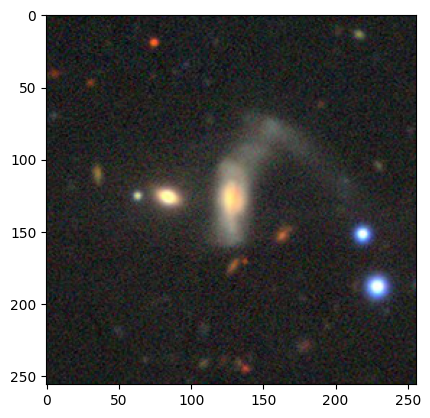

In [ ]:
plt.imshow(images[0].astype(int))
print(images[0].shape)

these images are quite large and colored. our inputs are therefore much larger.

now we need to make a train/test split. for this case, random splitting is fine

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(labels.shape[0]), test_size=0.1)
train_images, train_labels, test_images, test_labels = images[train_idx], labels[train_idx], images[test_idx], labels[test_idx]

TODO: test out which batch size is optimal for these images

now we can create noisy datasets for these

In [ ]:
scheduler = NoiseScheduler(T=1000, beta_start=1e-4, beta_end=0.02)
train_set_noisy = NoisyDataset(train_images,scheduler)
test_set_noisy = NoisyDataset(test_images,scheduler)


## 2. Build a UNet

the question here becomes: how do we have to adapt the unet to deal with colored images? or do we rather first set the images black and white? and how do we scale down the image quality? do we use autoencoders for that?

we first change the autoencoder architecture to allow for different numbers of input channels. then we try to train it a little bit and see how well that works. then, we try to see if latent diffusion could improve things.

In [ ]:
from typing import List

import torch
import torch.nn as nn
import torch.nn.functional as F
from modelRCTransformer import ResConvBlock,SinusoidalTimeEmbedding,TransformerBlock2D

In [ ]:
class UNet(nn.Module):

    def __init__(self, channels: List[int] = [32, 64, 128], convs_per_level=2,
             kernel_size=3, pool_size=2, padding=1, num_heads_att=4,
             time_emb_dim=128, time_emb_base_dim=32, input_channels=1):
        super().__init__()

        full_channels = [input_channels] + channels + channels[-2::-1]
        self.mid = len(full_channels) // 2

        self.encoder_convs = nn.ModuleList([
          nn.ModuleList([
              ResConvBlock(
                  in_ch=full_channels[i] if j == 0 else full_channels[i+1],
                  out_ch=full_channels[i+1],
                  time_emb_dim=time_emb_dim
              )
              for j in range(convs_per_level)
          ])
          for i in range(self.mid)
      ])

        self.decoder_convs = nn.ModuleList([
          nn.ModuleList([
              ResConvBlock(
                  in_ch=(full_channels[self.mid + i] + full_channels[self.mid - i - 1]) if j == 0
                      else full_channels[self.mid + i + 1],
                  out_ch=full_channels[self.mid + i + 1],
                  time_emb_dim=time_emb_dim
              )
              for j in range(convs_per_level)
          ])
          for i in range(len(full_channels) - self.mid - 1)
      ])

        #time embedding
        self.time_embedding = SinusoidalTimeEmbedding(
            d=time_emb_base_dim,
            hidden_dim=time_emb_dim
        )

        #attention
        bottleneck_channels = full_channels[self.mid]
    
        if num_heads_att < 2:
            self.attention = nn.Identity()
        else:
            assert bottleneck_channels % num_heads_att == 0, (
                f"number of heads for attention is invalid"
            )
            self.attention = TransformerBlock2d(
              bottleneck_channels,
              num_heads=num_heads_att,
              ff_mult=4,
              dropout=0.0,
              )

        self.output_conv = nn.Conv2d(full_channels[-1], input_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(pool_size)
        self.upsample = nn.Upsample(scale_factor=pool_size)
        self.activation_fn = F.relu

        self.config = {
            'channels':        channels,
            'convs_per_level': convs_per_level,
            'kernel_size':     kernel_size,
            'pool_size':       pool_size,
            'padding':         padding,
            'num_heads_att':   num_heads_att,
            'time_emb_dim':    time_emb_dim,
            'time_emb_base_dim': time_emb_base_dim,
        }

    def forward(self, x, t=None):
      t_emb = None if t is None else self.time_embedding(t)
      
      skips = []
      last_encoder = len(self.encoder_convs) - 1
      
      # ENCODER
      for i, conv_block in enumerate(self.encoder_convs):
          for block in conv_block:
              x = block(x, t_emb)  
          
          if i < last_encoder:
              skips.append(x)
              x = self.pool(x)
      
      # BOTTLENECK
      x = self.attention(x)
      
      # DECODER
      for i, conv_block in enumerate(self.decoder_convs):
          x = self.upsample(x)
          x = torch.cat([x, skips.pop()], dim=1)
          
          for block in conv_block:
              x = block(x, t_emb)  
      
      return self.output_conv(x)

### TO SET

In [ ]:
channel0 = 128
cpl = 2 

# model_path = '/home/scur0036/diffusion-models-project/models/base_C0_128_convs_2wd_1e-6_long.pkl'

In [ ]:
channels = channel_list(channel0) 
                      # convs per level

unet = UNet(channels=channels, convs_per_level=cpl,input_channels=3).to(device)
# if you want to train an existing model already, use load_unet
# unet = load_unet(model_path, channels=channels, convs_per_level=cpl)
# where model_path is the path to the state_dict .pkl file

print(f"Model: {model_name(channel0, cpl)}")
print(f"Parameters: {sum(p.numel() for p in unet.parameters()):,}")

## 3. Find a learning rate

we first try to figure some things out (batch_size, how long things take, etc) on colab, and when we have that figured out, we switch to sending jobs to snellius

In [ ]:
# suggested_lr = find_lr(unet, train_loader)
# lr = suggested_lr * 0.5
# print(f"Suggested LR: {suggested_lr:.2e} → using {lr:.2e}")

## 4. Train

### TO SET

In [ ]:
# if we train in the notebook
# save_path = path_name(channel0, cpl,add_desc="wd_1e-6")   # e.g. "base_C0_64_convs_2.pkl"

job_name = 'unet_C0_128_convs_2_galaxy_data'

either we train in this notebook itself

In [ ]:


# train_losses, test_losses = train(
#     unet, train_loader, test_loader,
#     epochs=50,
#     lr=lr,
#     weight_decay=1e-6,
#     early_stopping_patience=10,
#     save_path=save_path,
# )

### Send training to cluster
alternatively, a separate job can be send to a node to train the model

In [ ]:
batch_size = 32

In [ ]:
from cluster import train_on_cluster, job_status

# submit

job_id, save_path = train_on_cluster(
    unet,train_set_noisy,test_set_noisy,
    epochs=50,
    job_name=job_name,
)

### check job status

In [ ]:
job_status(job_id)

or simply

In [ ]:
! squeue

load trained model

In [ ]:
from cluster import get_save_path,get_losses_path
# load weights
unet.load_state_dict(torch.load(get_save_path(job_name),map_location=device))

# load losses
losses = torch.load(get_losses_path(job_name))
train_losses,test_losses = losses['train'],losses['test']


Plot the loss curves manually (training doesn't do this anymore):

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(train_losses,test_losses):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train')
    plt.plot(test_losses,  label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Loss curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
plot_loss(train_losses,test_losses)

## 6. Generate images

In [ ]:
x = generate_image(unet, scheduler, stochasticity=1.0, n_images=8)
plot_generated(x, ncol=4)

### Intermediates

In [ ]:
x_final, intermediates = generate_image(
    unet, scheduler, stochasticity=1.0, n_images=1, return_intermediates=True
)

# Plot every 100th step
fig, axes = plt.subplots(1, 11, figsize=(22, 2))
steps_to_show = list(range(0, 1000, 100)) + [999]
for ax, idx in zip(axes, steps_to_show):
    img = intermediates[idx].squeeze()
    if img.min() < 0:
        img = (img + 1) / 2
    ax.imshow(img.clamp(0, 1), cmap='gray')
    ax.set_title(f't={1000 - idx}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()